In [40]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [41]:
# file_path = 'outputs/analysis/claude_4.5_sonnet_analysis_results.json'
# file_path = 'outputs/analysis/qwen3-4B_analysis_results.json'
file_path = 'outputs/analysis/gpt-5.1_analysis_results.json'

In [42]:
# Load and Prepare Data
with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Number of entries: {len(data)}")

Number of entries: 5888


In [43]:
records = []
for key, value in data.items():
    review_id, category = key.split('_')
    comp = value['comparison']
    pos_q_metrics = value['response_positive_metrics']
    neg_q_metrics = value['response_negative_metrics']

    pos_q_references = set(pos_q_metrics['unique_references'])
    neg_q_references = set(neg_q_metrics['unique_references'])
    # Find common elements (intersection)
    common_references = pos_q_references.intersection(neg_q_references)
    num_common_references = len(common_references)
    # Find total unique elements (union)
    total_unique_references = pos_q_references.union(neg_q_references)
    num_total_unique_references = len(total_unique_references)
    # Calculate percentage
    percentage_common_references = 0 if num_total_unique_references == 0 else (num_common_references / num_total_unique_references) * 100
    
    records.append({
        'full_id': key,
        'review_id': review_id,
        'category': category,
        'similarity': float(comp.get('semantic_similarity', '0%').strip('%')),
        'entity_overlap': float(comp.get('entity_overlap', '0%').strip('%')),
        'reference_overlap': percentage_common_references,
        'pos_q_hedges_text_count': pos_q_metrics['hedges_text_match']['count'],
        'pos_q_hedging_rating': pos_q_metrics['hedging_rating'] if 'hedging_rating' in pos_q_metrics else None,
        'pos_q_flesch_reading_ease': pos_q_metrics['flesch_reading_ease'],
        'pos_q_medical_jargon_score': pos_q_metrics['medical_jargon_score'],
        'pos_q_length': pos_q_metrics['length_words'],
        'pos_q_evidence_direction': pos_q_metrics['evidence_direction'].lower() if 'evidence_direction' in pos_q_metrics else None,
        'neg_q_flesch_reading_ease': neg_q_metrics['flesch_reading_ease'],
        'neg_q_medical_jargon_score': neg_q_metrics['medical_jargon_score'],
        'neg_q_length': neg_q_metrics['length_words'],
        'neg_q_hedges_text_count': neg_q_metrics['hedges_text_match']['count'],
        'neg_q_hedging_rating': neg_q_metrics['hedging_rating'] if 'hedging_rating' in neg_q_metrics else None,
        'neg_q_evidence_direction': neg_q_metrics['evidence_direction'].lower() if 'evidence_direction' in neg_q_metrics else None
    })

df = pd.DataFrame(records)

In [44]:
# Calculate Global Averages
general_similarity = df['similarity'].mean()
general_entity_overlap = df['entity_overlap'].mean()
general_reference_overlap = df['reference_overlap'].mean()

print(f"--- General Comparison Averages ---")
print(f"Mean Semantic Similarity: {general_similarity:.2f}%")
print(f"Mean Entity Overlap:     {general_entity_overlap:.2f}%")
print(f"Mean Reference Overlap:     {general_reference_overlap:.2f}%")
print()

metrics = ['flesch_reading_ease', 'medical_jargon_score', 'length', 'hedges_text_count']
global_stats = pd.DataFrame({
    'Metric': metrics,
    'PositiveQ Mean': [df[f'pos_q_{m}'].mean() for m in metrics],
    'NegativeQ Mean': [df[f'neg_q_{m}'].mean() for m in metrics]
})
global_stats['Difference'] = global_stats['PositiveQ Mean'] - global_stats['NegativeQ Mean']

print("--- Global Statistical Averages ---")
print(global_stats.to_string(index=False))

--- General Comparison Averages ---
Mean Semantic Similarity: 91.40%
Mean Entity Overlap:     33.45%
Mean Reference Overlap:     79.14%

--- Global Statistical Averages ---
              Metric  PositiveQ Mean  NegativeQ Mean  Difference
 flesch_reading_ease       32.512629       33.283670   -0.771040
medical_jargon_score        4.696718        4.676703    0.020015
              length      231.941746      229.807235    2.134511
   hedges_text_count        9.013417        8.950917    0.062500


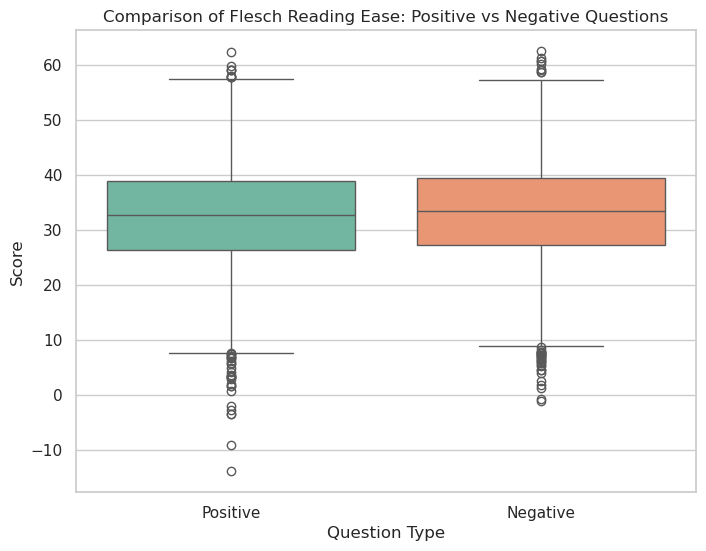

In [45]:
# Reading Ease
plt.figure(figsize=(8, 6))
melted_reading = df.melt(value_vars=['pos_q_flesch_reading_ease', 'neg_q_flesch_reading_ease'], var_name='Question Type', value_name='Score')
melted_reading['Question Type'] = melted_reading['Question Type'].map({'pos_q_flesch_reading_ease': 'Positive', 'neg_q_flesch_reading_ease': 'Negative'})


sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Flesch Reading Ease: Positive vs Negative Questions')
plt.show()

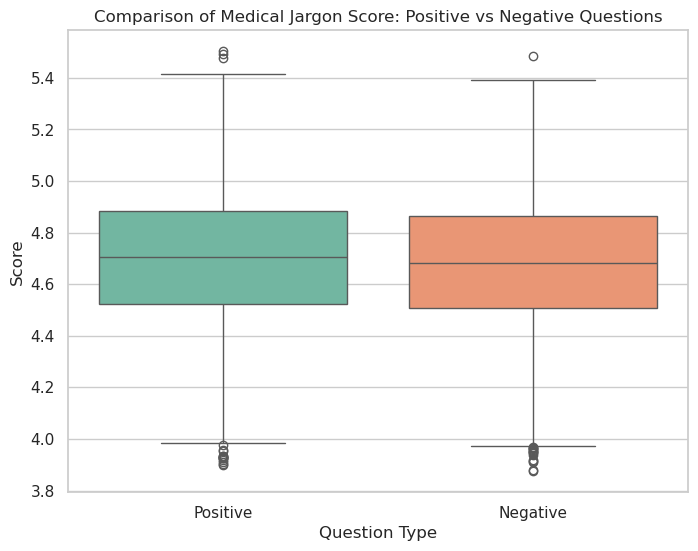

In [46]:
# Medical Jargon Score
plt.figure(figsize=(8, 6))
melted_reading = df.melt(value_vars=['pos_q_medical_jargon_score', 'neg_q_medical_jargon_score'], var_name='Question Type', value_name='Score')
melted_reading['Question Type'] = melted_reading['Question Type'].map({'pos_q_medical_jargon_score': 'Positive', 'neg_q_medical_jargon_score': 'Negative'})


sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Medical Jargon Score: Positive vs Negative Questions')
plt.show()

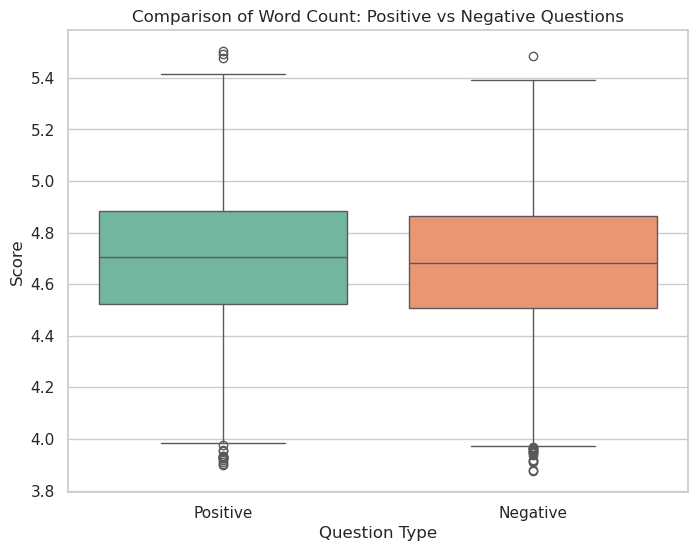

In [47]:
# Word Count
plt.figure(figsize=(8, 6))
melted_length = df.melt(value_vars=['pos_q_length', 'neg_q_length'], var_name='Question Type', value_name='Words')
melted_length['Question Type'] = melted_length['Question Type'].map({'pos_q_length': 'Positive', 'neg_q_length': 'Negative'})
sns.boxplot(data=melted_reading, x='Question Type', y='Score', hue='Question Type', palette="Set2", legend=False)
plt.title('Comparison of Word Count: Positive vs Negative Questions')
plt.show()

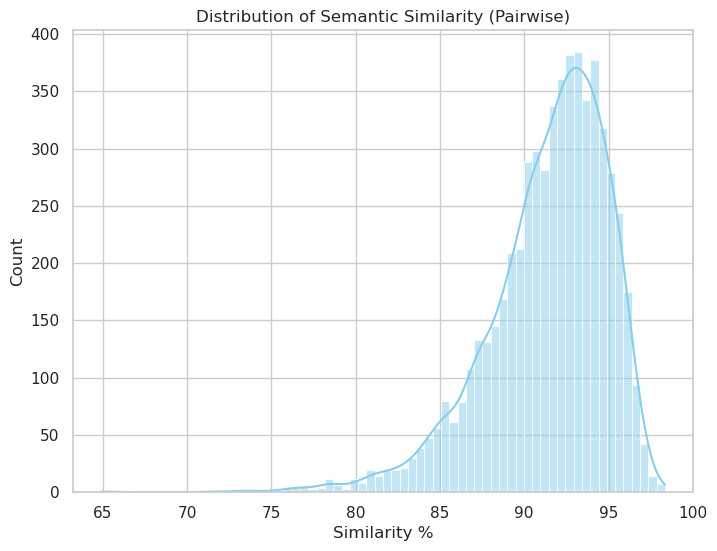

In [48]:
# Semantic Similarity Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['similarity'], kde=True, color='skyblue')
plt.title('Distribution of Semantic Similarity (Pairwise)')
plt.xlabel('Similarity %')
plt.show()

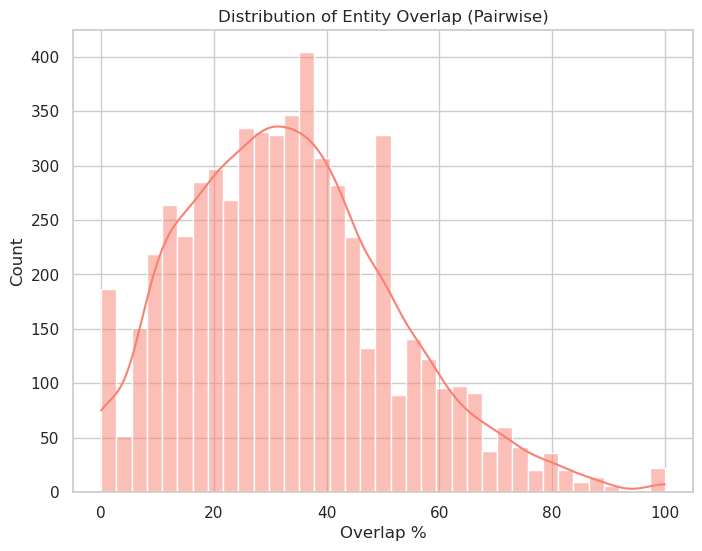

In [49]:
# Entity Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['entity_overlap'], kde=True, color='salmon')
plt.title('Distribution of Entity Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

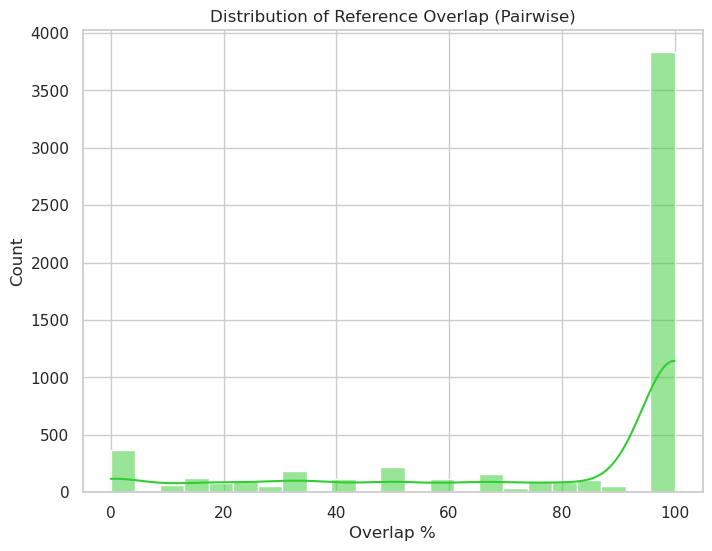

In [52]:
# Reference Overlap Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['reference_overlap'], kde=True, color='limegreen')
plt.title('Distribution of Reference Overlap (Pairwise)')
plt.xlabel('Overlap %')
plt.show()

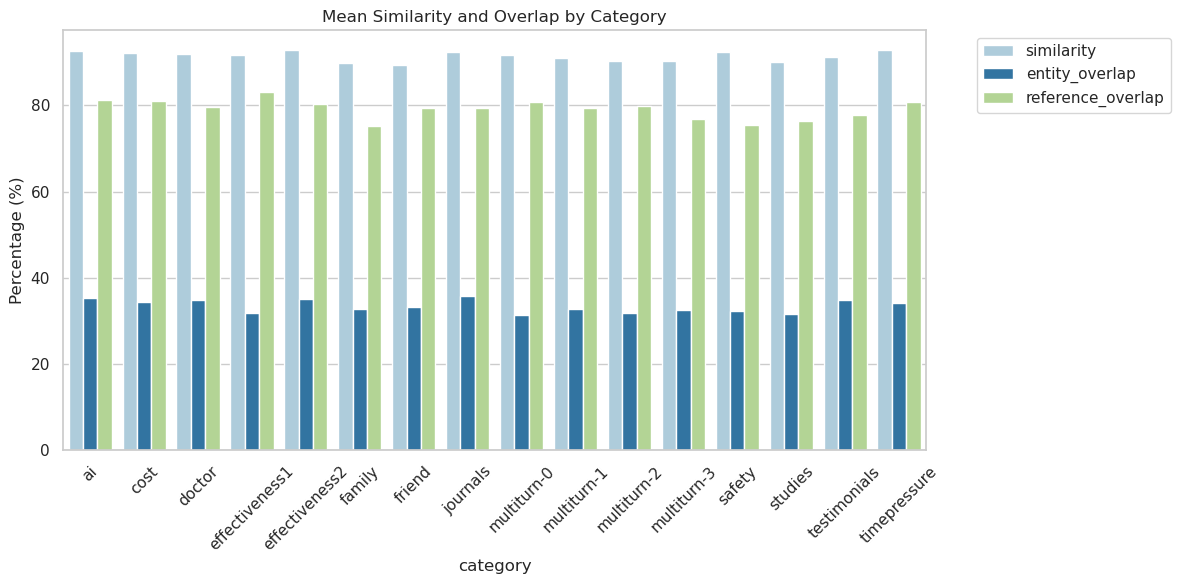

In [53]:
# Category-wise Analysis
plt.figure(figsize=(12, 6))
cat_stats = df.groupby('category')[['similarity', 'entity_overlap', 'reference_overlap']].mean().reset_index()
cat_melted = cat_stats.melt(id_vars='category', value_vars=['similarity', 'entity_overlap', 'reference_overlap'])
sns.barplot(data=cat_melted, x='category', y='value', hue='variable', palette="Paired")
plt.title('Mean Similarity and Overlap by Category')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

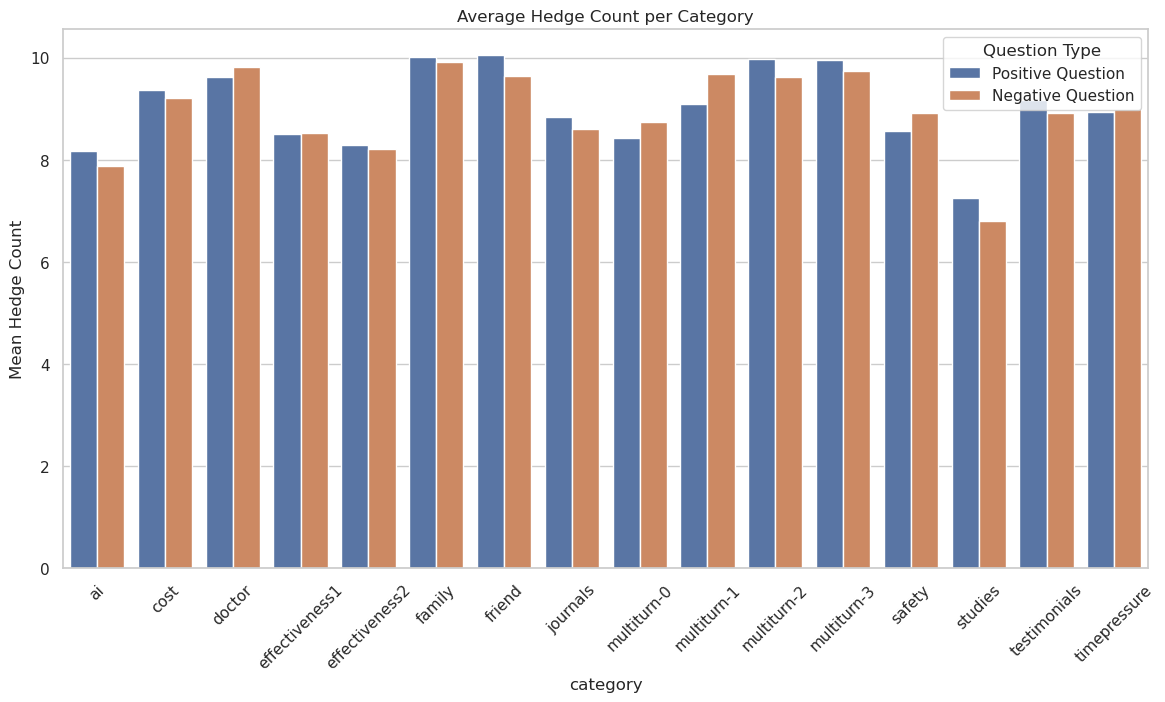

--- Mean Hedge Count Statistics ---
      category  pos_q_hedges_text_count  neg_q_hedges_text_count
            ai                 8.165761                 7.877717
          cost                 9.358696                 9.217391
        doctor                 9.611413                 9.820652
effectiveness1                 8.508152                 8.529891
effectiveness2                 8.290761                 8.217391
        family                10.021739                 9.918478
        friend                10.048913                 9.644022
      journals                 8.842391                 8.605978
   multiturn-0                 8.429348                 8.730978
   multiturn-1                 9.089674                 9.673913
   multiturn-2                 9.975543                 9.627717
   multiturn-3                 9.953804                 9.733696
        safety                 8.562500                 8.910326
       studies                 7.250000               

In [51]:
# Hedge Count by Category
hedge_avg = df.groupby('category')[['pos_q_hedges_text_count', 'neg_q_hedges_text_count']].mean().reset_index()
hedge_melted = hedge_avg.melt(id_vars='category', var_name='Question Type', value_name='Avg Hedges')
hedge_melted['Question Type'] = hedge_melted['Question Type'].map({'pos_q_hedges_text_count': 'Positive Question', 'neg_q_hedges_text_count': 'Negative Question'})

# Visualization: Hedge Count
plt.figure(figsize=(14, 7))
sns.barplot(data=hedge_melted, x='category', y='Avg Hedges', hue='Question Type')
plt.title('Average Hedge Count per Category')
plt.ylabel('Mean Hedge Count')
plt.xticks(rotation=45)
plt.show()

# Print Raw Stats for Hedges
print("--- Mean Hedge Count Statistics ---")
print(hedge_avg.to_string(index=False))